# (i)

In [24]:
import numpy as np
import seaborn as sns
# Mean and covariance
mu = [0, 0]
Sigma = [[25, 15],
         [15, 18]]

# Simulate 10,000 observations

def polar_method(n = 10000):
    # Returns N(0,1) samples
    U = np.random.uniform(-1, 1, (2,2*n))
    # Mask for uniform unit disk
    x = np.linalg.norm(U, axis = 0)
    mask = x <= 1
    V = U[:,mask]
    normalize = V / np.linalg.norm(V, axis = 0)
    Y = np.sqrt(-2*np.log(np.linalg.norm(V, axis = 0)**2))
    Y = Y * normalize
    return Y

Z = polar_method()[:,0:10000]

Cholesky decomposition gives:
$$
\Sigma = AA^T \iff A = \begin{bmatrix}
5 & 0 \\
3 & 3
\end{bmatrix}
$$

In [25]:
A = np.array([[5,0],
              [3,3]])
A @ A.T

array([[25, 15],
       [15, 18]])

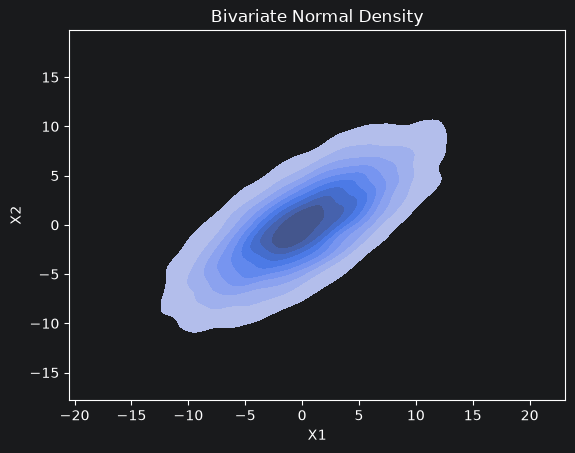

In [26]:
X =  A@Z
sns.kdeplot(x=X[0, :], y=X[1, :], fill=True)
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Bivariate Normal Density")
plt.show()

# (ii)
Again we do a cholesky decomposition of the covariance matrix. This is done by hand

In [27]:
A = np.array([[1,0,0],
              [1/2, np.sqrt(3) / 2, 0],
              [0, -1 / np.sqrt(3), np.sqrt(2) / np.sqrt(3)]])
A @ A.T

array([[ 1. ,  0.5,  0. ],
       [ 0.5,  1. , -0.5],
       [ 0. , -0.5,  1. ]])

We may then create a multivariate normal from vectors of normals, in accordance with section 3.3 in the lecture notes

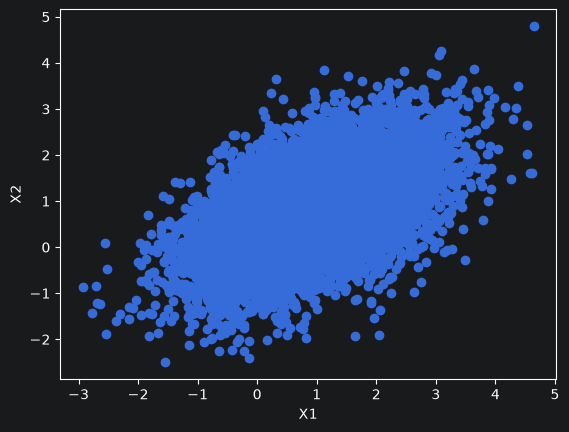

In [28]:
import matplotlib.pyplot as plt
# Mean and covariance
mu = np.ones((3,1))


# Simulate 10,000 observations of three dimensional Z
Z = np.random.normal(0, 1, size=(3, 10000))
X = mu + A @ Z

# Extract X1,X2 | X3 > 0
mask = X[2,:] > 0
X12 = X[0:2, mask]

plt.scatter(X12[0,:], X12[1, :])
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()


To simulate
$X1,X2 | X_3 = 0$ we can use proposition 3.3

In [29]:
Sigma = A @ A.T
d = 3
p  = 2
q =  d - p
# _p denotes ' and _pp ''
Sigma_p = Sigma[0:p, 0:p]
Sigma_pp = Sigma[p:, p:]
Sigma_0 = Sigma[0:p, p:]
mu_p = mu[0:p,:]
mu_pp = mu[p:,:]

x_pp = np.zeros((q,1))


mu_cond = mu_p + Sigma_0 @ np.linalg.inv(Sigma_pp) @ (x_pp-mu_pp)
Sigma_cond = Sigma_p - Sigma_0 @ np.linalg.inv(Sigma_pp) @ Sigma_0.T
Sigma_cond

array([[1.  , 0.5 ],
       [0.5 , 0.75]])

We find A

In [30]:
A = np.array([[1,0],
              [1/2,1/np.sqrt(2)]])
# Sample vectors of Standard Normal
A @A.T

array([[1.  , 0.5 ],
       [0.5 , 0.75]])

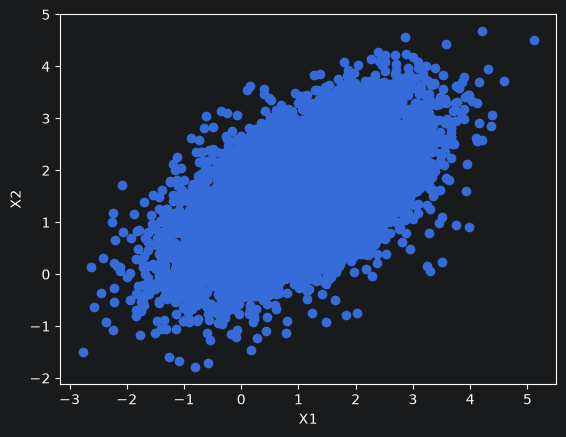

In [31]:

Z = np.random.normal(0, 1, size=(2, 10000))
X = mu_cond + A @ Z

plt.scatter(X[0,:], X[1,:])
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()